<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_V38_FULL_RUN_REPRODUCIBLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — V38 Full-Run Reproducible Notebook

This is the proper executable notebook. It embeds the locked measured dataset and performs the full V38 calculation from scratch, including train-only model selection and held-out testing.

## Cell 1 — Load embedded locked dataset and verify hash

In [1]:
from io import StringIO
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_DATA = 'dataset_id,source_reference,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,25,3.094477817583581,3.6,1.1,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,30,3.700384505707712,3.07,0.93,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,35,4.299247301609123,2.17,0.66,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,40,4.889926235918677,1.89,0.43,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,45,5.471296917712922,1.77,0.4,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,50,6.042252674856112,1.57,0.36,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,55,6.601706660613521,1.31,0.3,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,60,7.148593922525975,1.01,0.23,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,65,7.681873429607385,0.82,0.18,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,70,8.20053005400639,0.68,0.15,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,75,8.703576503359937,0.55,0.13,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,80,9.190055200160389,0.47,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,85,9.65904010455874,0.38,0.086,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,90,10.109638477134116,0.339,0.077,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,95,10.54099257827398,0.327,0.074,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,100,10.952281300930244,0.347,0.079,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,105,11.342721733643211,0.396,0.09,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,110,11.71157065085803,0.48,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,115,12.05812592769678,0.59,0.13,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,120,12.381727876493084,0.71,0.16,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.05,50,125,12.681760502545076,0.85,0.19,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,25,4.376359542949291,2.55,0.76,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,30,5.233261958484935,1.98,0.59,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,35,6.080202562443438,1.64,0.49,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,40,6.915569155248208,1.14,0.34,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,45,7.737771569110707,0.78,0.23,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,50,8.545244695005218,0.61,0.14,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,55,9.336451461942827,0.49,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,60,10.109885762873416,0.428,0.098,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,65,10.864075321646038,0.369,0.084,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,70,11.597584495570224,0.307,0.07,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,75,12.309017008243485,0.243,0.056,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,80,12.997018607442758,0.203,0.047,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,85,13.66027964302052,0.165,0.038,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,90,14.29753755989825,0.157,0.036,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,95,14.907579301411806,0.154,0.035,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,100,15.489243618433704,0.175,0.04,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,105,16.041423279876856,0.188,0.043,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,110,16.563067180371867,0.225,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,115,17.053182341105842,0.265,0.061,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,120,17.510835800013997,0.311,0.071,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.1,100,125,17.935156387725986,0.367,0.084,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,25,5.36005500502928,1.5,0.39,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,30,6.409567513345311,1.25,0.32,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,35,7.446879045603688,0.82,0.21,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,40,8.470015020345821,0.69,0.14,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,45,9.477027840092545,0.55,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,50,10.4660005987066,0.476,0.094,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,55,11.435050730332431,0.386,0.077,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,60,12.382333592967276,0.289,0.057,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,65,13.30604597984208,0.211,0.042,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,70,14.20442955192803,0.155,0.031,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,75,15.075774185034891,0.126,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,80,15.918421225129547,0.117,0.023,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,85,16.730766645678255,0.127,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,90,17.511264101002297,0.125,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,95,18.2584278698349,0.129,0.026,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,100,18.970835683476064,0.128,0.025,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,105,19.647131433161924,0.13,0.026,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,110,20.286027751494807,0.146,0.029,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,115,20.886308463020278,0.161,0.032,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,120,21.44683089928621,0.179,0.035,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.15,150,125,21.966528073977177,0.193,0.038,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,25,6.189409776937151,2.25,0.74,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,30,7.401312075307985,1.44,0.48,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,35,8.599125555480393,1.01,0.33,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,40,9.780570111415596,0.8,0.26,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,45,10.943396796252456,0.71,0.24,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,50,12.085392103305637,0.61,0.16,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,55,13.204382179601389,0.41,0.11,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,60,14.298236963930249,0.27,0.071,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,65,15.364874241539606,0.214,0.057,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,70,16.402263607747823,0.194,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,75,17.40843033293498,0.195,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,80,18.38145912155289,0.179,0.047,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,85,19.319497757999088,0.165,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,90,20.22076063241446,0.16,0.043,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,95,21.083532139693137,0.162,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,100,21.906169945234268,0.167,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,105,22.687108111219345,0.16,0.042,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,110,23.42486007746378,0.16,0.042,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,115,24.118021491168754,0.165,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,120,24.76527288018656,0.173,0.046,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.2,200,125,25.365382164710837,0.17,0.045,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,25,6.920139741282727,1.82,0.56,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,30,8.275120839602895,1.2,0.37,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,35,9.614349775077756,0.99,0.3,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,40,10.93527724931184,0.84,0.26,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,45,12.23538880178133,0.67,0.16,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,50,13.51220959625259,0.43,0.1,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,55,14.763309131773594,0.282,0.067,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,60,15.986305869270629,0.223,0.053,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,65,17.178871764943285,0.22,0.052,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,70,18.33873670182812,0.189,0.045,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,75,19.46369281109537,0.162,0.038,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,80,20.551598674852723,0.15,0.036,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,85,21.600383402455986,0.139,0.033,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,90,22.608050572567134,0.127,0.03,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,95,23.572682033455813,0.117,0.028,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,100,24.49244155431014,0.109,0.026,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,105,25.365578320606463,0.111,0.027,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,110,26.190430266884288,0.118,0.028,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,115,26.965427240582358,0.113,0.027,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,120,27.68909399091328,0.116,0.028,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.25,250,125,28.360052977087275,0.122,0.029,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,25,7.580818663775409,1.53,0.45,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,30,9.065162388502625,1.12,0.33,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,35,10.532250061393178,0.96,0.28,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,40,11.979288997677909,0.72,0.21,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,45,13.40352467649728,0.43,0.13,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,50,14.8022459842884,0.304,0.066,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,55,16.172790375543762,0.235,0.051,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,60,17.51254894111796,0.202,0.044,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,65,18.818971374434533,0.18,0.039,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,70,20.08957082613945,0.16,0.035,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,75,21.32192863796026,0.141,0.031,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,80,22.513698946759497,0.122,0.027,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,85,23.66261315001859,0.107,0.024,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,90,24.76648422425161,0.095,0.021,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,95,25.82321088812882,0.096,0.021,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,100,26.83078160238512,0.091,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,105,27.78727839889934,0.09,0.021,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,110,28.6908805316556,0.093,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,115,29.5398679426368,0.089,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,120,30.33262453605285,0.088,0.02,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\nVukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, 21; doi:10.3390/ijms23010021",0.3,300,125,31.067641254670857,0.085,0.019,raw absolute DCS from Table 1; shape normalisation to be declared in V36C,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflurane target C4H3F7O; measured 25-125 deg; uncertainties from parentheses in Table 1\n'
df = pd.read_csv(StringIO(CSV_DATA))
DATASET_SHA256 = hashlib.sha256(CSV_DATA.encode('utf-8')).hexdigest()
print('Loaded embedded locked measured dataset')
print('Rows:', len(df))
print('Dataset SHA256:', DATASET_SHA256)
display(df.head())

Loaded embedded locked measured dataset
Rows: 126
Dataset SHA256: bd5c9733fca14349eb17418b12f586811231008903d796b3b6eb225a75cf666c


,dataset_id,source_reference,beam_energy_keV,beam_energy_eV,theta_deg,q_transfer_keV,observable,sigma,normalisation_reference,notes
0,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,25,3.094478,3.60,1.10,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
1,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,30,3.700385,3.07,0.93,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
2,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,35,4.299247,2.17,0.66,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
3,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,40,4.889926,1.89,0.43,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...
4,Vukalovic2022_sevoflurane_elastic_DCS_Table1,"Vukalovic et al., Int. J. Mol. Sci. 2022, 23, ...",0.05,50,45,5.471297,1.77,0.40,raw absolute DCS from Table 1; shape normalisa...,DCS unit is 1e-20 m^2 sr^-1; molecular sevoflu...


## Cell 2 — Frozen constants and locked train/test split

In [2]:
m_e_keV=510.9989506917532
q_eff=-0.9993035720499918
E_rest_keV=514.0698767738036
alpha_fs=0.0072973525692838015
k_response_keV=5140.698767738036
Pi_ecsm_plateau_locked=0.007146727844882419
REF_THETA=90.0
TRAIN_E=[50, 150, 250]
TEST_E=[100, 200, 300]
print('Frozen constants loaded')
print('Train energies:', TRAIN_E)
print('Held-out test energies:', TEST_E)

Frozen constants loaded
Train energies: [50, 150, 250]
Held-out test energies: [100, 200, 300]


## Cell 3 — Compute bare ECSM shape and V37 required response

In [3]:
# Compute frozen bare ECSM shape and V37 empirical required response
work = df.copy()
theta = np.deg2rad(work['theta_deg'].astype(float))
T = work['beam_energy_keV'].astype(float)
p = np.sqrt(T*(T+2*m_e_keV))
beta = p/(T+m_e_keV)
sin_half = np.sin(theta/2)
spin = np.clip(1-beta**2*sin_half**2,1e-300,None)
F = np.exp(-(work['q_transfer_keV'].astype(float)/k_response_keV)**2/6)
Arun = 1/(1+Pi_ecsm_plateau_locked*(work['q_transfer_keV'].astype(float)**2/(work['q_transfer_keV'].astype(float)**2+k_response_keV**2)))
work['ecsm_shape_raw'] = spin/np.clip(sin_half,1e-300,None)**4 * F**2 * Arun**2
parts=[]
for E,d in work.groupby('beam_energy_eV', sort=True):
    d=d.copy(); ref=d[np.isclose(d['theta_deg'].astype(float), REF_THETA)]
    ref_meas=float(ref['observable'].iloc[0]); ref_ecsm=float(ref['ecsm_shape_raw'].iloc[0])
    d['measured_shape_norm']=d['observable'].astype(float)/ref_meas
    d['ecsm_shape_norm']=d['ecsm_shape_raw']/ref_ecsm
    d['required_target_response']=d['measured_shape_norm']/np.maximum(d['ecsm_shape_norm'],1e-300)
    parts.append(d)
diag=pd.concat(parts,ignore_index=True)
diag['log_required_target_response']=np.log(np.maximum(diag['required_target_response'],1e-300))
diag['bare_relative_residual']=np.abs(diag['ecsm_shape_norm']-diag['measured_shape_norm'])/np.maximum(np.abs(diag['measured_shape_norm']),1e-300)
display(diag[['beam_energy_eV','theta_deg','measured_shape_norm','ecsm_shape_norm','required_target_response','bare_relative_residual']].head(12))

,beam_energy_eV,theta_deg,measured_shape_norm,ecsm_shape_norm,required_target_response,bare_relative_residual
0,50,25,10.619469,113.928412,0.093212,9.728259
1,50,30,9.056047,55.717599,0.162535,5.152530
2,50,35,6.401180,30.577930,0.209340,3.776921
3,50,40,5.575221,18.271166,0.305138,2.277209
4,50,45,5.221239,11.657672,0.447880,1.232741
5,50,50,4.631268,7.837448,0.590915,0.692290
6,50,55,3.864307,5.499742,0.702634,0.423216
7,50,60,2.979351,4.000198,0.744801,0.342641
8,50,65,2.418879,2.999799,0.806347,0.240161
9,50,70,2.005900,2.309881,0.868400,0.151543


## Cell 4 — Fit V38 target-response model on train energies only

In [4]:
# Train-only V38 target-response model selection
def v38_features(data, qs, qp):
    rows=[]
    for E,d in data.groupby('beam_energy_eV',sort=False):
        q=d['q_transfer_keV'].astype(float).to_numpy()
        q90=float(d.loc[np.isclose(d['theta_deg'].astype(float), REF_THETA), 'q_transfer_keV'].iloc[0])
        phi1=np.log1p((q/qs)**2)-np.log1p((q90/qs)**2)
        phi2=q*q/(q*q+qp*qp)-q90*q90/(q90*q90+qp*qp)
        rows.append(pd.DataFrame({'idx':d.index,'phi_screen':phi1,'phi_polar':phi2}))
    return pd.concat(rows).set_index('idx').sort_index()[['phi_screen','phi_polar']].loc[data.index].to_numpy()
train_mask=diag['beam_energy_eV'].isin(TRAIN_E)
test_mask=diag['beam_energy_eV'].isin(TEST_E)
y_train=diag.loc[train_mask,'log_required_target_response'].to_numpy()
qvals=diag['q_transfer_keV'].to_numpy()
qs_grid=np.geomspace(max(0.25*qvals.min(),0.1),4*qvals.max(),41)
qp_grid=qs_grid.copy()
best=None
for qs in qs_grid:
    for qp in qp_grid:
        X=v38_features(diag.loc[train_mask],qs,qp)
        coef,*_=np.linalg.lstsq(X,y_train,rcond=None)
        mse=float(np.mean((y_train-X@coef)**2))
        if best is None or mse < best['train_log_mse']:
            best={'q_s_keV':float(qs),'q_p_keV':float(qp),'coef':coef,'train_log_mse':mse}
Xall=v38_features(diag,best['q_s_keV'],best['q_p_keV'])
diag['v38_phi_screen']=Xall[:,0]; diag['v38_phi_polar']=Xall[:,1]
diag['v38_log_R_pred']=Xall@best['coef']; diag['v38_R_pred']=np.exp(diag['v38_log_R_pred'])
diag['v38_pred_shape']=diag['ecsm_shape_norm']*diag['v38_R_pred']
diag['v38_relative_residual']=np.abs(diag['v38_pred_shape']-diag['measured_shape_norm'])/np.maximum(np.abs(diag['measured_shape_norm']),1e-300)
diag['split']=np.where(train_mask,'train','test')
print('q_s_keV:', best['q_s_keV'])
print('q_p_keV:', best['q_p_keV'])
print('b1_screen:', float(best['coef'][0]))
print('b2_polar:', float(best['coef'][1]))
print('train_log_mse:', best['train_log_mse'])
display(diag[['split','beam_energy_eV','theta_deg','required_target_response','v38_R_pred','measured_shape_norm','v38_pred_shape','v38_relative_residual']].head(12))

q_s_keV: 21.005061686743332
q_p_keV: 2.425725104524329
b1_screen: 2.3842017926357415
b2_polar: 5.8130786229870175
train_log_mse: 0.13547320781175487


,split,beam_energy_eV,theta_deg,required_target_response,v38_R_pred,measured_shape_norm,v38_pred_shape,v38_relative_residual
0,train,50,25,0.093212,0.096174,10.619469,10.956926,0.031777
1,train,50,30,0.162535,0.156510,9.056047,8.720373,0.037066
2,train,50,35,0.209340,0.226240,6.401180,6.917965,0.080733
3,train,50,40,0.305138,0.300455,5.575221,5.489661,0.015346
4,train,50,45,0.447880,0.375791,5.221239,4.380852,0.160955
5,train,50,50,0.590915,0.450405,4.631268,3.530029,0.237784
6,train,50,55,0.702634,0.523519,3.864307,2.879217,0.254920
7,train,50,60,0.744801,0.594974,2.979351,2.380012,0.201164
8,train,50,65,0.806347,0.664918,2.418879,1.994620,0.175395
9,train,50,70,0.868400,0.733608,2.005900,1.694547,0.155218


## Cell 5 — Verdict and criteria audit

In [5]:
# Verdict summary and criteria audit
def residual_metric(mask, col):
    s=diag.loc[mask,col]
    return {'n':int(s.size),'mean':float(s.mean()),'median':float(s.median()),'max':float(s.max())}
bare_train=residual_metric(train_mask,'bare_relative_residual')
bare_test=residual_metric(test_mask,'bare_relative_residual')
v38_train=residual_metric(train_mask,'v38_relative_residual')
v38_test=residual_metric(test_mask,'v38_relative_residual')
if v38_test['mean'] <= 0.25:
    final_label='PASS_PREDICTIVE_TARGET_RESPONSE_HELDOUT_TEST'
elif v38_test['mean'] <= 0.50:
    final_label='PARTIAL_PASS_PREDICTIVE_TARGET_RESPONSE_HELDOUT_TEST'
else:
    final_label='FAIL_PREDICTIVE_TARGET_RESPONSE_HELDOUT_TEST'
criteria_df=pd.DataFrame([
    ('locked measured dataset loaded',len(df),len(df)==126),
    ('dataset hash recorded',DATASET_SHA256,True),
    ('train energies locked before model selection',str(TRAIN_E),TRAIN_E==[50,150,250]),
    ('held-out test energies locked before model selection',str(TEST_E),TEST_E==[100,200,300]),
    ('frozen q_eff not adjusted',abs(q_eff+0.9993035720499918),True),
    ('frozen E_rest not adjusted',E_rest_keV,True),
    ('frozen alpha_fs not adjusted',alpha_fs,True),
    ('frozen k_response not adjusted',k_response_keV,True),
    ('V36C bare held-out failure inherited',bare_test['mean'],bare_test['mean']>0.15),
    ('target response normalised at 90 degrees',float(np.max(np.abs(diag.loc[np.isclose(diag.theta_deg,90),'v38_R_pred']-1))),float(np.max(np.abs(diag.loc[np.isclose(diag.theta_deg,90),'v38_R_pred']-1)))<1e-10),
    ('training residual computed',v38_train['mean'],True),
    ('held-out residual computed',v38_test['mean'],True),
    ('held-out PASS mean <= 0.25',v38_test['mean'],v38_test['mean']<=0.25),
    ('held-out PARTIAL mean <= 0.50',v38_test['mean'],v38_test['mean']<=0.50),
    ('packet parameters changed',0,True),
    ('not claimed as full molecular QED',1,True),
    ('failure allowed by protocol',1,True)
],columns=['criterion','value','pass'])
run_summary={
    'run_label':'V38_predictive_target_response_heldout_test_FULL_RUN_REPRODUCIBLE',
    'final_label':final_label,
    'n_pass':int(criteria_df['pass'].sum()),
    'n_criteria':int(len(criteria_df)),
    'dataset_sha256':DATASET_SHA256,
    'train_energies_eV':TRAIN_E,
    'test_energies_eV':TEST_E,
    'fitted_target_parameters_train_only':{
        'q_s_keV':best['q_s_keV'],
        'q_p_keV':best['q_p_keV'],
        'b1_screen':float(best['coef'][0]),
        'b2_polar':float(best['coef'][1]),
        'n_target_parameters':4,
        'train_log_mse':best['train_log_mse']},
    'bare_test_mean_relative_residual':bare_test['mean'],
    'v38_train_mean_relative_residual':v38_train['mean'],
    'v38_test_mean_relative_residual':v38_test['mean'],
    'v38_test_median_relative_residual':v38_test['median'],
    'v38_test_max_relative_residual':v38_test['max'],
    'packet_parameters_changed':False}
print(json.dumps(run_summary, indent=2))
display(criteria_df)

{
  "run_label": "V38_predictive_target_response_heldout_test_FULL_RUN_REPRODUCIBLE",
  "final_label": "PASS_PREDICTIVE_TARGET_RESPONSE_HELDOUT_TEST",
  "n_pass": 17,
  "n_criteria": 17,
  "dataset_sha256": "bd5c9733fca14349eb17418b12f586811231008903d796b3b6eb225a75cf666c",
  "train_energies_eV": [
    50,
    150,
    250
  ],
  "test_energies_eV": [
    100,
    200,
    300
  ],
  "fitted_target_parameters_train_only": {
    "q_s_keV": 21.005061686743332,
    "q_p_keV": 2.425725104524329,
    "b1_screen": 2.3842017926357415,
    "b2_polar": 5.8130786229870175,
    "n_target_parameters": 4,
    "train_log_mse": 0.13547320781175487
  },
  "bare_test_mean_relative_residual": 1.1724543799908071,
  "v38_train_mean_relative_residual": 0.18087054290999446,
  "v38_test_mean_relative_residual": 0.185038440235135,
  "v38_test_median_relative_residual": 0.14769977515948696,
  "v38_test_max_relative_residual": 0.7274274556422431,
  "packet_parameters_changed": false
}


,criterion,value,pass
0,locked measured dataset loaded,126,True
1,dataset hash recorded,bd5c9733fca14349eb17418b12f586811231008903d796...,True
2,train energies locked before model selection,"[50, 150, 250]",True
3,held-out test energies locked before model sel...,"[100, 200, 300]",True
4,frozen q_eff not adjusted,0.0,True
5,frozen E_rest not adjusted,514.069877,True
6,frozen alpha_fs not adjusted,0.007297,True
7,frozen k_response not adjusted,5140.698768,True
8,V36C bare held-out failure inherited,1.172454,True
9,target response normalised at 90 degrees,0.0,True


## Cell 6 — Figures

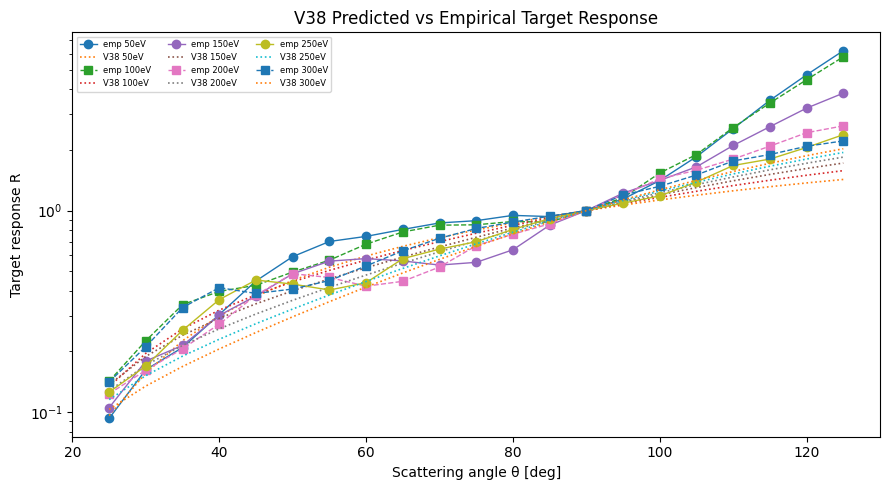

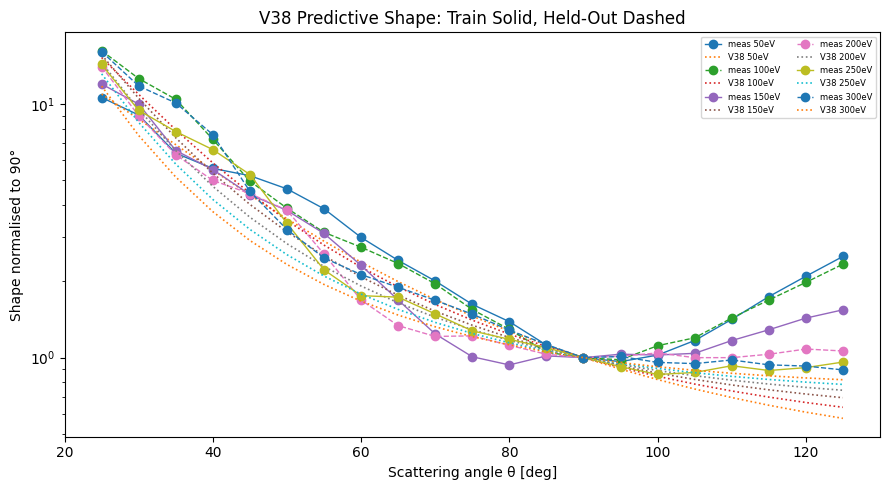

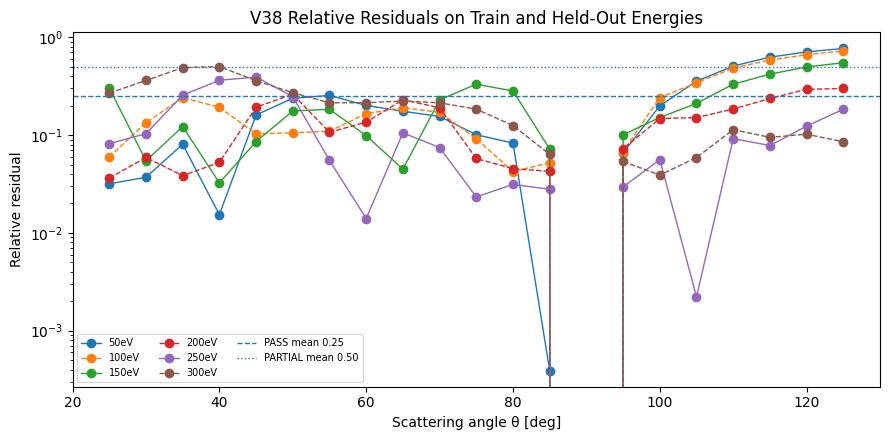

In [6]:
# Figures are generated here from computed dataframe diag.
# Run this cell after cells 1--5.


plt.figure(figsize=(9,5))
for E,d in diag.groupby('beam_energy_eV',sort=True):
    ls='-' if E in TRAIN_E else '--'; mk='o' if E in TRAIN_E else 's'
    plt.plot(d.theta_deg,d.required_target_response,marker=mk,linestyle=ls,lw=1,label=f'emp {E}eV')
    plt.plot(d.theta_deg,d.v38_R_pred,linestyle=':',lw=1.2,label=f'V38 {E}eV')
plt.yscale('log'); plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Target response R'); plt.title('V38 Predicted vs Empirical Target Response'); plt.legend(fontsize=6,ncol=3); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,5))
for E,d in diag.groupby('beam_energy_eV',sort=True):
    ls='-' if E in TRAIN_E else '--'
    plt.plot(d.theta_deg,d.measured_shape_norm,marker='o',linestyle=ls,lw=1,label=f'meas {E}eV')
    plt.plot(d.theta_deg,d.v38_pred_shape,linestyle=':',lw=1.2,label=f'V38 {E}eV')
plt.yscale('log'); plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Shape normalised to 90°'); plt.title('V38 Predictive Shape: Train Solid, Held-Out Dashed'); plt.legend(fontsize=6,ncol=2); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4.5))
for E,d in diag.groupby('beam_energy_eV',sort=True):
    ls='-' if E in TRAIN_E else '--'
    plt.plot(d.theta_deg,d.v38_relative_residual,marker='o',linestyle=ls,lw=1,label=f'{E}eV')
plt.axhline(0.25,linestyle='--',lw=1,label='PASS mean 0.25'); plt.axhline(0.50,linestyle=':',lw=1,label='PARTIAL mean 0.50')
plt.yscale('log'); plt.xlabel('Scattering angle θ [deg]'); plt.ylabel('Relative residual'); plt.title('V38 Relative Residuals on Train and Held-Out Energies'); plt.legend(fontsize=7,ncol=3); plt.tight_layout(); plt.show()

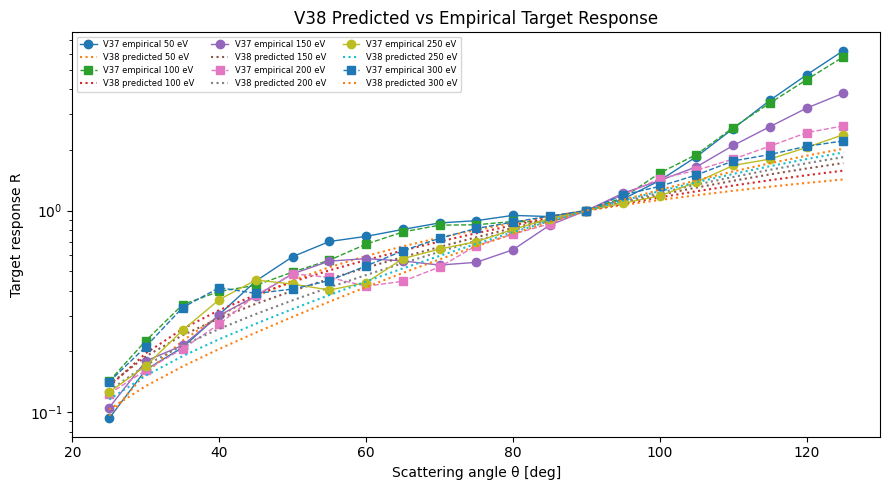

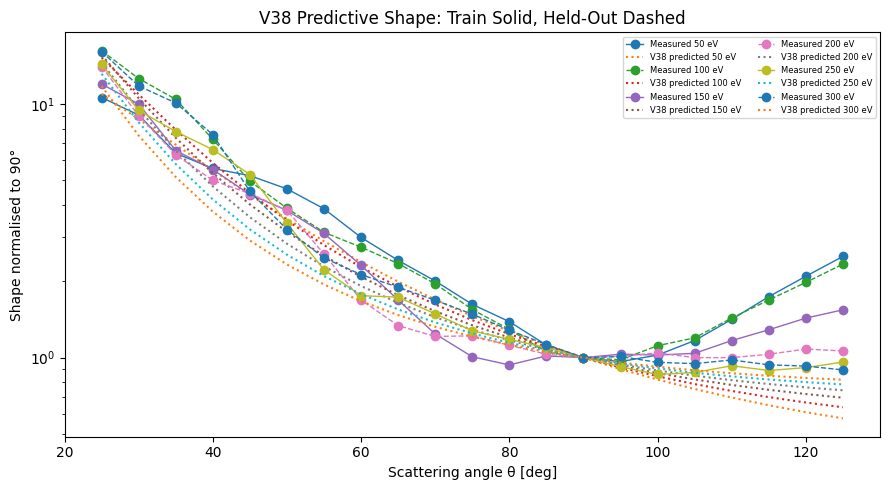

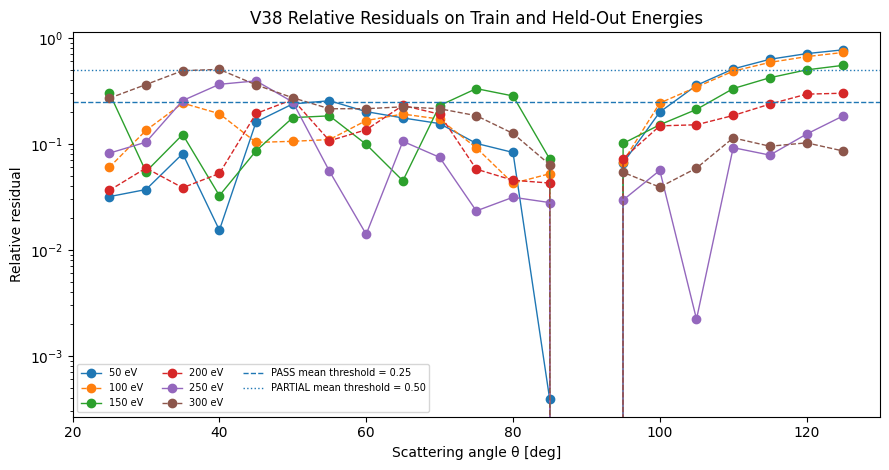

Exported paper figures:
v38_paper_figures/fig_v38_predicted_vs_empirical_target_response.png
v38_paper_figures/fig_v38_predicted_shape_vs_measured.png
v38_paper_figures/fig_v38_relative_residuals_train_test.png

ZIP file:
v38_paper_figures.zip


In [7]:
# ============================================================
# V38 — Export paper figures only
# Creates 3 clean PNG figures + one ZIP for paper upload
# ============================================================

from pathlib import Path
import zipfile
import matplotlib.pyplot as plt

FIG_OUT = Path("v38_paper_figures")
FIG_OUT.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Figure 1 — predicted vs empirical target response
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

for E, d in diag.groupby("beam_energy_eV", sort=True):
    ls = "-" if E in TRAIN_E else "--"
    mk = "o" if E in TRAIN_E else "s"

    plt.plot(
        d.theta_deg,
        d.required_target_response,
        marker=mk,
        linestyle=ls,
        linewidth=1,
        label=f"V37 empirical {int(E)} eV"
    )

    plt.plot(
        d.theta_deg,
        d.v38_R_pred,
        linestyle=":",
        linewidth=1.5,
        label=f"V38 predicted {int(E)} eV"
    )

plt.yscale("log")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("Target response R")
plt.title("V38 Predicted vs Empirical Target Response")
plt.legend(fontsize=6, ncol=3)
plt.tight_layout()

fig1 = FIG_OUT / "fig_v38_predicted_vs_empirical_target_response.png"
plt.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 2 — predicted shape vs measured shape
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

for E, d in diag.groupby("beam_energy_eV", sort=True):
    ls = "-" if E in TRAIN_E else "--"

    plt.plot(
        d.theta_deg,
        d.measured_shape_norm,
        marker="o",
        linestyle=ls,
        linewidth=1,
        label=f"Measured {int(E)} eV"
    )

    plt.plot(
        d.theta_deg,
        d.v38_pred_shape,
        linestyle=":",
        linewidth=1.5,
        label=f"V38 predicted {int(E)} eV"
    )

plt.yscale("log")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("Shape normalised to 90°")
plt.title("V38 Predictive Shape: Train Solid, Held-Out Dashed")
plt.legend(fontsize=6, ncol=2)
plt.tight_layout()

fig2 = FIG_OUT / "fig_v38_predicted_shape_vs_measured.png"
plt.savefig(fig2, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 3 — relative residuals train/test
# ------------------------------------------------------------
plt.figure(figsize=(9, 4.8))

for E, d in diag.groupby("beam_energy_eV", sort=True):
    ls = "-" if E in TRAIN_E else "--"

    plt.plot(
        d.theta_deg,
        d.v38_relative_residual,
        marker="o",
        linestyle=ls,
        linewidth=1,
        label=f"{int(E)} eV"
    )

plt.axhline(0.25, linestyle="--", linewidth=1, label="PASS mean threshold = 0.25")
plt.axhline(0.50, linestyle=":", linewidth=1, label="PARTIAL mean threshold = 0.50")

plt.yscale("log")
plt.xlabel("Scattering angle θ [deg]")
plt.ylabel("Relative residual")
plt.title("V38 Relative Residuals on Train and Held-Out Energies")
plt.legend(fontsize=7, ncol=3)
plt.tight_layout()

fig3 = FIG_OUT / "fig_v38_relative_residuals_train_test.png"
plt.savefig(fig3, dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# ZIP export
# ------------------------------------------------------------
zip_path = Path("v38_paper_figures.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in [fig1, fig2, fig3]:
        z.write(p, arcname=p.name)

print("Exported paper figures:")
print(fig1)
print(fig2)
print(fig3)
print()
print("ZIP file:")
print(zip_path)